# Cost function experiment

This notebook searches for robust cost-function settings for two separate decisions:

1. **Peak-to-peak linking:** connect detections across adjacent frames into candidate trajectories.
2. **Trajectory-to-trajectory assignment:** assign recovered candidate trajectories to simulated ground truth.

The two stages are tuned separately. Peak-to-peak settings are evaluated with a fixed trajectory-to-GT evaluator, then the best peak-to-peak setting is used to generate a fixed candidate set for the trajectory-to-trajectory sweep. The final cell saves a report-ready six-panel figure with panel letters.

In [1]:
from pathlib import Path
import os
import sys
import copy
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from helpers.helpersSimulation import Simulator
from helpers.helpersTracking import (
    extract_peaks,
    track_from_peaks,
    track_peaks_to_trajectories,
    PeakToPeak,
    DistanceTerm,
    IntensityTerm,
    SigmaTerm,
)
from helpers.helpersAssignment import (
    TrajToTraj,
    MeanPositionDistanceTerm,
    LengthDifferenceTerm,
    StartFrameDifferenceTerm,
    assign_trajectories,
    compute_cost_matrix_trajectories,
)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
})

OUT_DIR = PROJECT_ROOT / "Experiments"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking


## Experiment design

The default grid is sized to run interactively while still probing robustness across random seeds, motion blur/density difficulty, and photon noise. Increase `N_SEEDS` or add entries to `DIFFICULTY_GRID` for a slower final analysis.

The peak-to-peak sweep uses Gaussian-localized detections so distance, intensity, and fitted sigma are all available. In the current simulator intensity and sigma fluctuate per subframe, so the analysis can also reveal when these metadata terms are too noisy to help.

In [2]:
N_SEEDS = 4
SEEDS = list(range(N_SEEDS))
DIFFICULTY_GRID = [(3, 80), (5, 100), (7, 140)]

D_LIST = [
    (0.10, 0.30),
    (0.50, 0.10),
    (1.50, 0.15),
    (3.50, 0.10),
    (4.00, 0.15),
    (5.00, 0.20),
]

SIM_CONFIG_BASE = {
    "nparticles": 12,
    "nframes": 35,
    "nposframe": 5,
    "D_list": D_LIST,
    "dt": 1.0,
    "anisotropy_ratio_range": (1.0, 1.0),
    "theta_range": (np.deg2rad(30), np.deg2rad(30)),
    "frame_size": (128, 128),
    "intensity_mean": 700,
    "intensity_std": 300,
    "sigma_mean": 1.0,
    "sigma_std": 0.2,
}

IMAGE_CONFIG_BASE = {
    "particle_intensity": [700, 300],
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
    "use_trajectory_sigma": False,
}

TRACKING_KWARGS = {
    "mode": "localization",
    "detection_threshold": 400,
    "r_squared_threshold": 0.45,
    "max_distance": 8.0,
    "min_length": 5,
    "max_gap": 1,
    "algo_peak2peak": "hungarian",
    "algo_traj2traj": "hungarian",
}

PEAK_NORMS = {
    "distance": TRACKING_KWARGS["max_distance"],
    "intensity": IMAGE_CONFIG_BASE["particle_intensity"][0],
    "sigma": 0.75,
}
TRAJ_NORMS = {
    "position": TRACKING_KWARGS["max_distance"],
    "length": 10.0,
    "start_frame": 5.0,
}

ASSIGNMENT_COST_LIMIT = 5.0
TRUTH_MATCH_TOLERANCE_PX = 3.0
FORCE_RERUN = False

RESULT_PATHS = {
    "peak": OUT_DIR / "CostExperiment_peak2peak_results.csv",
    "traj": OUT_DIR / "CostExperiment_traj2traj_results.csv",
    "summary": OUT_DIR / "CostExperiment_recommendations.csv",
    "figure_png": OUT_DIR / "CostExperiment_key_panels.png",
    "figure_pdf": OUT_DIR / "CostExperiment_key_panels.pdf",
}

print(f"Simulations: {len(SEEDS) * len(DIFFICULTY_GRID)}")

Simulations: 12


## Cost grids

Each term is normalized first, then weighted. This makes the weights interpretable as relative importance rather than unit conversion constants.

In [3]:
PEAK_COST_SPECS = [
    {"name": "distance_only", "family": "ablation", "distance": 1.00, "intensity": 0.00, "sigma": 0.00},
    {"name": "intensity_only", "family": "ablation", "distance": 0.00, "intensity": 1.00, "sigma": 0.00},
    {"name": "sigma_only", "family": "ablation", "distance": 0.00, "intensity": 0.00, "sigma": 1.00},
    {"name": "dist_int_90_10", "family": "distance_intensity", "distance": 0.90, "intensity": 0.10, "sigma": 0.00},
    {"name": "dist_int_75_25", "family": "distance_intensity", "distance": 0.75, "intensity": 0.25, "sigma": 0.00},
    {"name": "dist_int_60_40", "family": "distance_intensity", "distance": 0.60, "intensity": 0.40, "sigma": 0.00},
    {"name": "dist_sig_90_10", "family": "distance_sigma", "distance": 0.90, "intensity": 0.00, "sigma": 0.10},
    {"name": "dist_sig_75_25", "family": "distance_sigma", "distance": 0.75, "intensity": 0.00, "sigma": 0.25},
    {"name": "dist_sig_60_40", "family": "distance_sigma", "distance": 0.60, "intensity": 0.00, "sigma": 0.40},
    {"name": "dist_meta_80_10_10", "family": "all_terms", "distance": 0.80, "intensity": 0.10, "sigma": 0.10},
    {"name": "dist_meta_70_20_10", "family": "all_terms", "distance": 0.70, "intensity": 0.20, "sigma": 0.10},
    {"name": "dist_meta_50_40_10", "family": "all_terms", "distance": 0.50, "intensity": 0.40, "sigma": 0.10},
    {"name": "equal_all", "family": "all_terms", "distance": 1/3, "intensity": 1/3, "sigma": 1/3},
]

TRAJ_COST_SPECS = [
    {"name": "position_only", "family": "ablation", "position": 1.00, "length": 0.00, "start_frame": 0.00},
    {"name": "length_only", "family": "ablation", "position": 0.00, "length": 1.00, "start_frame": 0.00},
    {"name": "start_only", "family": "ablation", "position": 0.00, "length": 0.00, "start_frame": 1.00},
    {"name": "pos_len_90_10", "family": "position_length", "position": 0.90, "length": 0.10, "start_frame": 0.00},
    {"name": "pos_len_75_25", "family": "position_length", "position": 0.75, "length": 0.25, "start_frame": 0.00},
    {"name": "pos_len_60_40", "family": "position_length", "position": 0.60, "length": 0.40, "start_frame": 0.00},
    {"name": "pos_start_90_10", "family": "position_start", "position": 0.90, "length": 0.00, "start_frame": 0.10},
    {"name": "pos_start_75_25", "family": "position_start", "position": 0.75, "length": 0.00, "start_frame": 0.25},
    {"name": "pos_start_60_40", "family": "position_start", "position": 0.60, "length": 0.00, "start_frame": 0.40},
    {"name": "pos_meta_80_10_10", "family": "all_terms", "position": 0.80, "length": 0.10, "start_frame": 0.10},
    {"name": "pos_meta_70_20_10", "family": "all_terms", "position": 0.70, "length": 0.20, "start_frame": 0.10},
    {"name": "pos_meta_60_20_20", "family": "all_terms", "position": 0.60, "length": 0.20, "start_frame": 0.20},
    {"name": "equal_all", "family": "all_terms", "position": 1/3, "length": 1/3, "start_frame": 1/3},
]


def build_peak_cost(spec):
    terms = {}
    if spec.get("distance", 0) > 0:
        terms["distance"] = DistanceTerm(weight=float(spec["distance"]), norm=PEAK_NORMS["distance"])
    if spec.get("intensity", 0) > 0:
        terms["intensity"] = IntensityTerm(weight=float(spec["intensity"]), norm=PEAK_NORMS["intensity"])
    if spec.get("sigma", 0) > 0:
        terms["sigma"] = SigmaTerm(weight=float(spec["sigma"]), norm=PEAK_NORMS["sigma"])
    return PeakToPeak(terms=terms)


def build_traj_cost(spec):
    terms = {}
    if spec.get("position", 0) > 0:
        terms["position"] = MeanPositionDistanceTerm(
            weight=float(spec["position"]),
            norm=TRAJ_NORMS["position"],
            invalid_cost=1e6,
        )
    if spec.get("length", 0) > 0:
        terms["length"] = LengthDifferenceTerm(weight=float(spec["length"]), norm=TRAJ_NORMS["length"])
    if spec.get("start_frame", 0) > 0:
        terms["start_frame"] = StartFrameDifferenceTerm(
            weight=float(spec["start_frame"]),
            norm=TRAJ_NORMS["start_frame"],
        )
    return TrajToTraj(terms=terms)


FIXED_TRAJ_EVALUATOR_SPEC = next(spec for spec in TRAJ_COST_SPECS if spec["name"] == "position_only")
FIXED_TRAJ_EVALUATOR = build_traj_cost(FIXED_TRAJ_EVALUATOR_SPEC)

display(pd.DataFrame(PEAK_COST_SPECS))
display(pd.DataFrame(TRAJ_COST_SPECS))

,name,family,distance,intensity,sigma
0,distance_only,ablation,1.000000,0.000000,0.000000
1,intensity_only,ablation,0.000000,1.000000,0.000000
2,sigma_only,ablation,0.000000,0.000000,1.000000
3,dist_int_90_10,distance_intensity,0.900000,0.100000,0.000000
4,dist_int_75_25,distance_intensity,0.750000,0.250000,0.000000
5,dist_int_60_40,distance_intensity,0.600000,0.400000,0.000000
6,dist_sig_90_10,distance_sigma,0.900000,0.000000,0.100000
7,dist_sig_75_25,distance_sigma,0.750000,0.000000,0.250000
8,dist_sig_60_40,distance_sigma,0.600000,0.000000,0.400000
9,dist_meta_80_10_10,all_terms,0.800000,0.100000,0.100000


,name,family,position,length,start_frame
0,position_only,ablation,1.000000,0.000000,0.000000
1,length_only,ablation,0.000000,1.000000,0.000000
2,start_only,ablation,0.000000,0.000000,1.000000
3,pos_len_90_10,position_length,0.900000,0.100000,0.000000
4,pos_len_75_25,position_length,0.750000,0.250000,0.000000
5,pos_len_60_40,position_length,0.600000,0.400000,0.000000
6,pos_start_90_10,position_start,0.900000,0.000000,0.100000
7,pos_start_75_25,position_start,0.750000,0.000000,0.250000
8,pos_start_60_40,position_start,0.600000,0.000000,0.400000
9,pos_meta_80_10_10,all_terms,0.800000,0.100000,0.100000


## Metrics

The main metrics are exact consecutive-frame link F1, recovered GT coverage, fragmentation, median position error, and independent track-label assignment accuracy. The objective is conservative: it rewards F1, coverage, and correct assignment, then penalizes fragmentation, position error, and high-cost assignments.

In [4]:
def finite_mean(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    return float(np.mean(values)) if len(values) else np.nan


def finite_median(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    return float(np.median(values)) if len(values) else np.nan


def finite_sem(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) <= 1:
        return np.nan
    return float(np.std(values, ddof=1) / np.sqrt(len(values)))


def valid_gt_id(gid, gt_by_id):
    return gid is not None and gid != -1 and gid in gt_by_id


def edge_counter(trajectories, require_valid_gt=True, gt_by_id=None):
    edges = Counter()
    for traj in trajectories:
        gid = traj.id
        if require_valid_gt and not valid_gt_id(gid, gt_by_id):
            continue
        frames = sorted(traj.frames())
        for f0, f1 in zip(frames[:-1], frames[1:]):
            if f1 == f0 + 1:
                edges[(int(gid), int(f0), int(f1))] += 1
    return edges


def precision_recall_f1(pred_edges, gt_edges):
    tp = sum(min(count, gt_edges.get(edge, 0)) for edge, count in pred_edges.items())
    fp = sum(pred_edges.values()) - tp
    fn = sum(gt_edges.values()) - tp
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0
        else np.nan
    )
    return precision, recall, f1, tp, fp, fn


def assigned_position_errors(trajectories, gt_by_id):
    errors = []
    for traj in trajectories:
        if not valid_gt_id(traj.id, gt_by_id):
            continue
        gt_traj = gt_by_id[traj.id]
        for frame in traj.frames():
            pos = traj.get_position_at_frame(frame)
            gt_pos = gt_traj.get_position_at_frame(frame)
            if pos is None or gt_pos is None:
                continue
            errors.append(float(np.linalg.norm(np.asarray(pos) - np.asarray(gt_pos))))
    return np.asarray(errors, dtype=float)


def coverage_and_fragments(trajectories, trajectories_GT):
    gt_by_id = {traj.id: traj for traj in trajectories_GT if traj.id is not None and traj.length() > 0}
    recovered_frames = {gid: set() for gid in gt_by_id}
    fragment_counts = {gid: 0 for gid in gt_by_id}
    assigned_tracks = 0
    unassigned_tracks = 0

    for traj in trajectories:
        if traj.length() == 0:
            continue
        if not valid_gt_id(traj.id, gt_by_id):
            unassigned_tracks += 1
            continue
        assigned_tracks += 1
        fragment_counts[traj.id] += 1
        gt_traj = gt_by_id[traj.id]
        for frame in traj.frames():
            if gt_traj.get_position_at_frame(frame) is not None:
                recovered_frames[traj.id].add(frame)

    coverage = []
    fragments = []
    for gid, gt_traj in gt_by_id.items():
        coverage.append(len(recovered_frames[gid]) / gt_traj.length())
        fragments.append(fragment_counts[gid])

    return {
        "coverage": np.asarray(coverage, dtype=float),
        "fragments": np.asarray(fragments, dtype=float),
        "assigned_tracks": assigned_tracks,
        "unassigned_tracks": unassigned_tracks,
    }


def truth_label_for_track(traj, trajectories_GT, tolerance_px=TRUTH_MATCH_TOLERANCE_PX):
    counts = Counter()
    all_best_distances = []

    for frame in traj.frames():
        pos = traj.get_position_at_frame(frame)
        if pos is None:
            continue
        best_gid = None
        best_distance = np.inf
        for gt in trajectories_GT:
            gt_pos = gt.get_position_at_frame(frame)
            if gt_pos is None:
                continue
            distance = float(np.linalg.norm(np.asarray(pos) - np.asarray(gt_pos)))
            if distance < best_distance:
                best_distance = distance
                best_gid = gt.id
        if np.isfinite(best_distance):
            all_best_distances.append(best_distance)
        if best_gid is not None and best_distance <= tolerance_px:
            counts[best_gid] += 1

    if not counts:
        return None, np.nan, finite_median(all_best_distances)

    label, label_count = counts.most_common(1)[0]
    purity = label_count / max(1, sum(counts.values()))
    return label, purity, finite_median(all_best_distances)


def assignment_label_metrics(trajectories, trajectories_GT):
    labelable = 0
    correct = 0
    weighted_total = 0
    weighted_correct = 0
    purities = []
    truth_errors = []

    for traj in trajectories:
        true_label, purity, truth_error = truth_label_for_track(traj, trajectories_GT)
        if np.isfinite(purity):
            purities.append(purity)
        if np.isfinite(truth_error):
            truth_errors.append(truth_error)
        if true_label is None or not np.isfinite(purity) or purity < 0.60:
            continue
        labelable += 1
        weighted_total += traj.length()
        is_correct = traj.id == true_label
        correct += int(is_correct)
        weighted_correct += traj.length() * int(is_correct)

    return {
        "labelable_tracks": labelable,
        "assignment_accuracy": correct / labelable if labelable else np.nan,
        "assignment_weighted_accuracy": weighted_correct / weighted_total if weighted_total else np.nan,
        "truth_label_purity": finite_mean(purities),
        "truth_label_median_error_px": finite_median(truth_errors),
    }


def assignment_diagnostics(assignment, cost_matrix, cost_limit=ASSIGNMENT_COST_LIMIT):
    assignment = list(assignment)
    n_rows, n_cols = cost_matrix.shape if getattr(cost_matrix, "ndim", 0) == 2 else (len(assignment), 0)
    valid_pairs = []
    invalid_count = 0
    for i, j in enumerate(assignment):
        if j is None or int(j) < 0 or int(j) >= n_cols:
            invalid_count += 1
            continue
        valid_pairs.append((i, int(j), float(cost_matrix[i, int(j)])))

    assigned_cols = [j for _, j, _ in valid_pairs]
    duplicate_gt_assignments = sum(count - 1 for count in Counter(assigned_cols).values() if count > 1)
    assigned_costs = np.asarray([cost for _, _, cost in valid_pairs], dtype=float)
    high_cost_assignments = int(np.sum(assigned_costs > cost_limit)) if len(assigned_costs) else 0
    invalid_cost_assignments = int(np.sum(assigned_costs >= 1e5)) if len(assigned_costs) else 0

    return {
        "n_assignment_rows": n_rows,
        "n_assignment_cols": n_cols,
        "n_assigned_pairs": len(valid_pairs),
        "n_unassigned_rows": invalid_count,
        "duplicate_gt_assignments": duplicate_gt_assignments,
        "high_cost_assignments": high_cost_assignments,
        "invalid_cost_assignments": invalid_cost_assignments,
        "assignment_mean_cost": finite_mean(assigned_costs),
        "assignment_median_cost": finite_median(assigned_costs),
    }


def score_labeled_trajectories(trajectories, trajectories_GT, runtime_s, cost_matrix=None, assignment=None, extra=None):
    gt_by_id = {traj.id: traj for traj in trajectories_GT if traj.id is not None and traj.length() > 0}
    gt_edges = edge_counter(trajectories_GT, require_valid_gt=False)
    pred_edges = edge_counter(trajectories, require_valid_gt=True, gt_by_id=gt_by_id)
    precision, recall, f1, tp, fp, fn = precision_recall_f1(pred_edges, gt_edges)
    errors = assigned_position_errors(trajectories, gt_by_id)
    cov_frag = coverage_and_fragments(trajectories, trajectories_GT)
    label_metrics = assignment_label_metrics(trajectories, trajectories_GT)

    row = {
        "runtime_s": runtime_s,
        "n_tracks": len([traj for traj in trajectories if traj.length() > 0]),
        "link_precision": precision,
        "link_recall": recall,
        "link_f1": f1,
        "link_tp": tp,
        "link_fp": fp,
        "link_fn": fn,
        "mean_coverage": finite_mean(cov_frag["coverage"]),
        "median_coverage": finite_median(cov_frag["coverage"]),
        "mean_fragments_per_gt": finite_mean(cov_frag["fragments"]),
        "max_fragments_per_gt": float(np.nanmax(cov_frag["fragments"])) if len(cov_frag["fragments"]) else np.nan,
        "assigned_tracks": cov_frag["assigned_tracks"],
        "unassigned_tracks": cov_frag["unassigned_tracks"],
        "median_position_error_px": finite_median(errors),
        "mean_position_error_px": finite_mean(errors),
        **label_metrics,
    }
    if assignment is not None and cost_matrix is not None:
        row.update(assignment_diagnostics(assignment, cost_matrix))
    else:
        row.update({
            "duplicate_gt_assignments": np.nan,
            "high_cost_assignments": np.nan,
            "invalid_cost_assignments": np.nan,
            "assignment_mean_cost": np.nan,
            "assignment_median_cost": np.nan,
        })
    if extra:
        row.update(extra)
    return row


def add_objectives(df):
    df = df.copy()
    frag_penalty = np.clip((df["mean_fragments_per_gt"].fillna(2.5) - 1.0) / 2.0, 0, 1)
    pos_penalty = np.clip(df["median_position_error_px"].fillna(TRACKING_KWARGS["max_distance"]) / TRACKING_KWARGS["max_distance"], 0, 1)
    dup_penalty = df["duplicate_gt_assignments"].fillna(0) / np.maximum(df["n_tracks"].fillna(1), 1)
    high_cost_penalty = df["high_cost_assignments"].fillna(0) / np.maximum(df["n_tracks"].fillna(1), 1)
    df["peak_objective"] = (
        0.50 * df["link_f1"].fillna(0)
        + 0.25 * df["mean_coverage"].fillna(0)
        + 0.15 * df["assignment_weighted_accuracy"].fillna(0)
        - 0.05 * frag_penalty
        - 0.03 * pos_penalty
        - 0.02 * high_cost_penalty
    )
    df["traj_objective"] = (
        0.40 * df["assignment_accuracy"].fillna(0)
        + 0.25 * df["assignment_weighted_accuracy"].fillna(0)
        + 0.20 * df["link_f1"].fillna(0)
        + 0.10 * df["mean_coverage"].fillna(0)
        - 0.03 * dup_penalty
        - 0.02 * high_cost_penalty
    )
    return df


def summarize_by_config(df, config_col, objective_col):
    rows = []
    metric_cols = [
        objective_col,
        "link_f1",
        "mean_coverage",
        "mean_fragments_per_gt",
        "median_position_error_px",
        "assignment_accuracy",
        "assignment_weighted_accuracy",
        "duplicate_gt_assignments",
        "high_cost_assignments",
        "runtime_s",
    ]
    for name, group in df.groupby(config_col):
        row = {config_col: name, "n": len(group)}
        for metric in metric_cols:
            values = group[metric].to_numpy(dtype=float)
            row[f"{metric}_mean"] = finite_mean(values)
            row[f"{metric}_ci95"] = 1.96 * finite_sem(values)
        rows.append(row)
    return pd.DataFrame(rows).sort_values(f"{objective_col}_mean", ascending=False).reset_index(drop=True)

## Simulation cache and sweep runners

In [5]:
def make_simulation(seed, nposframe, poisson_noise):
    sim_cfg = copy.deepcopy(SIM_CONFIG_BASE)
    sim_cfg["nposframe"] = int(nposframe)
    img_cfg = copy.deepcopy(IMAGE_CONFIG_BASE)
    img_cfg["poisson_noise"] = int(poisson_noise)
    sim = Simulator(sim_cfg, image_config=img_cfg, seed=seed).run()
    return sim, sim_cfg, img_cfg


def extract_peaks_once(sim):
    return extract_peaks(
        sim.frames,
        mode=TRACKING_KWARGS["mode"],
        detection_threshold=TRACKING_KWARGS["detection_threshold"],
        r_squared_threshold=TRACKING_KWARGS["r_squared_threshold"],
        verbose_loc=False,
        visualization_loc=False,
    )


def peak_count_summary(peaks):
    counts = np.asarray([len(frame_peaks) for frame_peaks in peaks], dtype=float)
    return {
        "total_peaks": int(np.sum(counts)),
        "mean_peaks_per_frame": finite_mean(counts),
        "median_peaks_per_frame": finite_median(counts),
    }


def build_simulation_cache():
    cache = []
    total = len(SEEDS) * len(DIFFICULTY_GRID)
    done = 0
    for nposframe, poisson_noise in DIFFICULTY_GRID:
        for seed in SEEDS:
            done += 1
            sim, sim_cfg, img_cfg = make_simulation(seed, nposframe, poisson_noise)
            peaks = extract_peaks_once(sim)
            peak_info = peak_count_summary(peaks)
            difficulty_label = f"npos={nposframe}, noise={poisson_noise}"
            cache.append({
                "seed": seed,
                "nposframe": int(nposframe),
                "poisson_noise": int(poisson_noise),
                "difficulty": difficulty_label,
                "sim": sim,
                "sim_cfg": sim_cfg,
                "img_cfg": img_cfg,
                "peaks": peaks,
                "peak_info": peak_info,
            })
            print(f"Cached {done}/{total}: seed={seed}, {difficulty_label}, peaks={peak_info['total_peaks']}")
    return cache


def run_peak2peak_sweep(sim_cache, peak_specs=PEAK_COST_SPECS):
    rows = []
    total = len(sim_cache) * len(peak_specs)
    done = 0
    for item in sim_cache:
        peaks = item["peaks"]
        sim = item["sim"]
        for spec in peak_specs:
            done += 1
            peak_cost = build_peak_cost(spec)
            t0 = time.perf_counter()
            trajectories, cost_peak2peak, assignment, cost_traj2traj = track_from_peaks(
                peaks,
                sim.trajectories_GT,
                max_distance=TRACKING_KWARGS["max_distance"],
                min_length=TRACKING_KWARGS["min_length"],
                max_gap=TRACKING_KWARGS["max_gap"],
                algo_peak2peak=TRACKING_KWARGS["algo_peak2peak"],
                cost_func_peak2peak=peak_cost,
                algo_traj2traj=TRACKING_KWARGS["algo_traj2traj"],
                cost_func_traj2traj=FIXED_TRAJ_EVALUATOR,
                verbose_assignment=False,
            )
            runtime_s = time.perf_counter() - t0
            cost_matrix = compute_cost_matrix_trajectories(
                trajectories,
                sim.trajectories_GT,
                cost_function=FIXED_TRAJ_EVALUATOR,
            ) if len(trajectories) else np.empty((0, len(sim.trajectories_GT)))
            rows.append(score_labeled_trajectories(
                trajectories,
                sim.trajectories_GT,
                runtime_s=runtime_s,
                cost_matrix=cost_matrix,
                assignment=assignment,
                extra={
                    "stage": "peak2peak",
                    "peak_config": spec["name"],
                    "peak_family": spec["family"],
                    "peak_distance_weight": spec["distance"],
                    "peak_intensity_weight": spec["intensity"],
                    "peak_sigma_weight": spec["sigma"],
                    "traj_config": FIXED_TRAJ_EVALUATOR_SPEC["name"],
                    "seed": item["seed"],
                    "nposframe": item["nposframe"],
                    "poisson_noise": item["poisson_noise"],
                    "difficulty": item["difficulty"],
                    **item["peak_info"],
                },
            ))
            if done % max(1, total // 10) == 0 or done == total:
                print(f"Peak-to-peak sweep {done}/{total}")
    return add_objectives(pd.DataFrame(rows))


def run_traj2traj_sweep(sim_cache, best_peak_spec, traj_specs=TRAJ_COST_SPECS):
    rows = []
    total = len(sim_cache) * len(traj_specs)
    done = 0
    best_peak_cost = build_peak_cost(best_peak_spec)
    for item in sim_cache:
        sim = item["sim"]
        peaks = item["peaks"]
        candidate_tracks, cost_peak2peak = track_peaks_to_trajectories(
            peaks,
            max_distance=TRACKING_KWARGS["max_distance"],
            min_length=TRACKING_KWARGS["min_length"],
            algorithm=TRACKING_KWARGS["algo_peak2peak"],
            cost_function=best_peak_cost,
            max_gap=TRACKING_KWARGS["max_gap"],
        )
        for spec in traj_specs:
            done += 1
            traj_cost = build_traj_cost(spec)
            candidates = copy.deepcopy(candidate_tracks)
            cost_matrix = compute_cost_matrix_trajectories(
                candidates,
                sim.trajectories_GT,
                cost_function=traj_cost,
            ) if len(candidates) else np.empty((0, len(sim.trajectories_GT)))
            t0 = time.perf_counter()
            trajectories, cost_traj2traj, assignment = assign_trajectories(
                candidates,
                sim.trajectories_GT,
                algorithm=TRACKING_KWARGS["algo_traj2traj"],
                cost_function=traj_cost,
                verbose=False,
            )
            runtime_s = time.perf_counter() - t0
            rows.append(score_labeled_trajectories(
                trajectories,
                sim.trajectories_GT,
                runtime_s=runtime_s,
                cost_matrix=cost_matrix,
                assignment=assignment,
                extra={
                    "stage": "traj2traj",
                    "peak_config": best_peak_spec["name"],
                    "peak_family": best_peak_spec["family"],
                    "peak_distance_weight": best_peak_spec["distance"],
                    "peak_intensity_weight": best_peak_spec["intensity"],
                    "peak_sigma_weight": best_peak_spec["sigma"],
                    "traj_config": spec["name"],
                    "traj_family": spec["family"],
                    "traj_position_weight": spec["position"],
                    "traj_length_weight": spec["length"],
                    "traj_start_frame_weight": spec["start_frame"],
                    "seed": item["seed"],
                    "nposframe": item["nposframe"],
                    "poisson_noise": item["poisson_noise"],
                    "difficulty": item["difficulty"],
                    "candidate_tracks": len(candidate_tracks),
                    **item["peak_info"],
                },
            ))
            if done % max(1, total // 10) == 0 or done == total:
                print(f"Trajectory-to-trajectory sweep {done}/{total}")
    return add_objectives(pd.DataFrame(rows))

## Run or load results

In [6]:
if (
    not FORCE_RERUN
    and RESULT_PATHS["peak"].exists()
    and RESULT_PATHS["traj"].exists()
):
    peak_df = pd.read_csv(RESULT_PATHS["peak"])
    traj_df = pd.read_csv(RESULT_PATHS["traj"])
    print("Loaded cached CostExperiment results.")
else:
    sim_cache = build_simulation_cache()
    peak_df = run_peak2peak_sweep(sim_cache)
    peak_df.to_csv(RESULT_PATHS["peak"], index=False)

    peak_summary_tmp = summarize_by_config(peak_df, "peak_config", "peak_objective")
    best_peak_name_tmp = peak_summary_tmp.iloc[0]["peak_config"]
    best_peak_spec_tmp = next(spec for spec in PEAK_COST_SPECS if spec["name"] == best_peak_name_tmp)
    traj_df = run_traj2traj_sweep(sim_cache, best_peak_spec_tmp)
    traj_df.to_csv(RESULT_PATHS["traj"], index=False)
    print("Saved new CostExperiment results.")

peak_df = add_objectives(peak_df)
traj_df = add_objectives(traj_df)
print(f"peak_df: {peak_df.shape}")
print(f"traj_df: {traj_df.shape}")
display(peak_df.head())

Cached 1/12: seed=0, npos=3, noise=80, peaks=485


Cached 2/12: seed=1, npos=3, noise=80, peaks=456


Cached 3/12: seed=2, npos=3, noise=80, peaks=437


Cached 4/12: seed=3, npos=3, noise=80, peaks=492


Cached 5/12: seed=0, npos=5, noise=100, peaks=458


...

Trajectory-to-trajectory sweep 120/156


Trajectory-to-trajectory sweep 135/156


Trajectory-to-trajectory sweep 150/156


Trajectory-to-trajectory sweep 156/156
Saved new CostExperiment results.
peak_df: (156, 46)
traj_df: (156, 51)


,runtime_s,n_tracks,link_precision,link_recall,link_f1,link_tp,link_fp,link_fn,mean_coverage,median_coverage,...,traj_config,seed,nposframe,poisson_noise,difficulty,total_peaks,mean_peaks_per_frame,median_peaks_per_frame,peak_objective,traj_objective
0,0.228529,33,1.0,0.250000,0.400000,102,0,306,0.307143,0.328571,...,position_only,0,3,80,"npos=3, noise=80",485,13.857143,13.0,0.326707,0.354641
1,0.239318,32,1.0,0.345588,0.513661,141,0,267,0.430952,0.414286,...,position_only,0,3,80,"npos=3, noise=80",485,13.857143,13.0,0.440684,0.457086
2,0.247642,25,1.0,0.438725,0.609881,179,0,229,0.521429,0.485714,...,position_only,0,3,80,"npos=3, noise=80",485,13.857143,13.0,0.525911,0.550538
3,0.269817,33,1.0,0.308824,0.471910,126,0,282,0.369048,0.328571,...,position_only,0,3,80,"npos=3, noise=80",485,13.857143,13.0,0.383089,0.373859
4,0.255822,34,1.0,0.340686,0.508227,139,0,269,0.404762,0.342857,...,position_only,0,3,80,"npos=3, noise=80",485,13.857143,13.0,0.417262,0.396831


## Recommendation tables

In [7]:
peak_summary = summarize_by_config(peak_df, "peak_config", "peak_objective")
traj_summary = summarize_by_config(traj_df, "traj_config", "traj_objective")

best_peak_name = peak_summary.iloc[0]["peak_config"]
best_traj_name = traj_summary.iloc[0]["traj_config"]
best_peak_spec = next(spec for spec in PEAK_COST_SPECS if spec["name"] == best_peak_name)
best_traj_spec = next(spec for spec in TRAJ_COST_SPECS if spec["name"] == best_traj_name)

recommendation_rows = []
for stage, name, spec, summary, config_col, objective_col in [
    ("peak2peak", best_peak_name, best_peak_spec, peak_summary, "peak_config", "peak_objective"),
    ("traj2traj", best_traj_name, best_traj_spec, traj_summary, "traj_config", "traj_objective"),
]:
    row = summary[summary[config_col] == name].iloc[0].to_dict()
    row.update({"stage": stage, "recommended_config": name, **spec})
    recommendation_rows.append(row)
recommendations = pd.DataFrame(recommendation_rows)
recommendations.to_csv(RESULT_PATHS["summary"], index=False)

print("Best peak-to-peak cost:")
print(best_peak_spec)
print("\nBest trajectory-to-trajectory cost:")
print(best_traj_spec)
print("\nPeak-to-peak top 8")
display(peak_summary.head(8))
print("Trajectory-to-trajectory top 8")
display(traj_summary.head(8))

Best peak-to-peak cost:
{'name': 'dist_meta_50_40_10', 'family': 'all_terms', 'distance': 0.5, 'intensity': 0.4, 'sigma': 0.1}

Best trajectory-to-trajectory cost:
{'name': 'pos_len_75_25', 'family': 'position_length', 'position': 0.75, 'length': 0.25, 'start_frame': 0.0}

Peak-to-peak top 8


,peak_config,n,peak_objective_mean,peak_objective_ci95,link_f1_mean,link_f1_ci95,mean_coverage_mean,mean_coverage_ci95,mean_fragments_per_gt_mean,mean_fragments_per_gt_ci95,...,assignment_accuracy_mean,assignment_accuracy_ci95,assignment_weighted_accuracy_mean,assignment_weighted_accuracy_ci95,duplicate_gt_assignments_mean,duplicate_gt_assignments_ci95,high_cost_assignments_mean,high_cost_assignments_ci95,runtime_s_mean,runtime_s_ci95
0,dist_meta_50_40_10,12,0.567071,0.054246,0.675582,0.056815,0.560913,0.060242,1.0,0.0,...,0.503325,0.048948,0.615740,0.074856,0.0,0.0,0.0,0.0,0.199924,0.026981
1,dist_int_60_40,12,0.563661,0.047545,0.676105,0.051591,0.557143,0.054176,1.0,0.0,...,0.489545,0.052554,0.597144,0.056973,0.0,0.0,0.0,0.0,0.176041,0.023818
2,intensity_only,12,0.560170,0.045262,0.660612,0.050216,0.560317,0.052068,1.0,0.0,...,0.528188,0.043106,0.622750,0.054684,0.0,0.0,0.0,0.0,0.171651,0.025715
3,sigma_only,12,0.553911,0.044727,0.655776,0.047173,0.546627,0.051540,1.0,0.0,...,0.536346,0.037925,0.618923,0.061772,0.0,0.0,0.0,0.0,0.168149,0.024516
4,dist_sig_60_40,12,0.545134,0.036577,0.657080,0.039509,0.536508,0.040489,1.0,0.0,...,0.486921,0.030414,0.571622,0.047669,0.0,0.0,0.0,0.0,0.177735,0.023890
5,dist_int_75_25,12,0.540424,0.052546,0.652254,0.055984,0.528770,0.057842,1.0,0.0,...,0.467290,0.054924,0.568829,0.068748,0.0,0.0,0.0,0.0,0.180612,0.025574
6,dist_meta_70_20_10,12,0.537051,0.051087,0.649002,0.055267,0.525397,0.056494,1.0,0.0,...,0.478261,0.051068,0.563173,0.064225,0.0,0.0,0.0,0.0,0.194762,0.029401
7,dist_sig_75_25,12,0.530460,0.037533,0.644320,0.039516,0.514881,0.042071,1.0,0.0,...,0.464556,0.026540,0.552479,0.050172,0.0,0.0,0.0,0.0,0.176537,0.022961


Trajectory-to-trajectory top 8


,traj_config,n,traj_objective_mean,traj_objective_ci95,link_f1_mean,link_f1_ci95,mean_coverage_mean,mean_coverage_ci95,mean_fragments_per_gt_mean,mean_fragments_per_gt_ci95,...,assignment_accuracy_mean,assignment_accuracy_ci95,assignment_weighted_accuracy_mean,assignment_weighted_accuracy_ci95,duplicate_gt_assignments_mean,duplicate_gt_assignments_ci95,high_cost_assignments_mean,high_cost_assignments_ci95,runtime_s_mean,runtime_s_ci95
0,pos_len_75_25,12,0.599260,0.040699,0.758385,0.040462,0.660714,0.046031,1.0,0.0,...,0.503325,0.048948,0.720726,0.047270,0.0,0.0,0.0,0.0,0.080298,0.005431
1,pos_len_60_40,12,0.596707,0.042249,0.765314,0.039187,0.671230,0.044143,1.0,0.0,...,0.493089,0.050587,0.717141,0.049468,0.0,0.0,0.0,0.0,0.081580,0.008417
2,pos_len_90_10,12,0.591677,0.043726,0.746920,0.045949,0.646825,0.052842,1.0,0.0,...,0.503325,0.048948,0.705122,0.053120,0.0,0.0,0.0,0.0,0.080215,0.008117
3,pos_meta_70_20_10,12,0.579679,0.044526,0.740232,0.042810,0.637302,0.046174,1.0,0.0,...,0.493096,0.050101,0.682655,0.055787,0.0,0.0,0.0,0.0,0.081535,0.010496
4,pos_meta_80_10_10,12,0.569471,0.045309,0.725310,0.043213,0.617460,0.047171,1.0,0.0,...,0.493096,0.050101,0.661700,0.057709,0.0,0.0,0.0,0.0,0.086799,0.009564
5,pos_meta_60_20_20,12,0.567487,0.046304,0.725191,0.042054,0.617063,0.046172,1.0,0.0,...,0.490120,0.052465,0.658780,0.058456,0.0,0.0,0.0,0.0,0.084627,0.006624
6,equal_all,12,0.561032,0.048516,0.725312,0.047005,0.618651,0.050454,1.0,0.0,...,0.479733,0.054011,0.648845,0.061497,0.0,0.0,0.0,0.0,0.079264,0.007443
7,position_only,12,0.546473,0.054031,0.675582,0.056815,0.560913,0.060242,1.0,0.0,...,0.503325,0.048948,0.615740,0.074856,0.0,0.0,0.0,0.0,0.073780,0.007012


## Report-ready figure

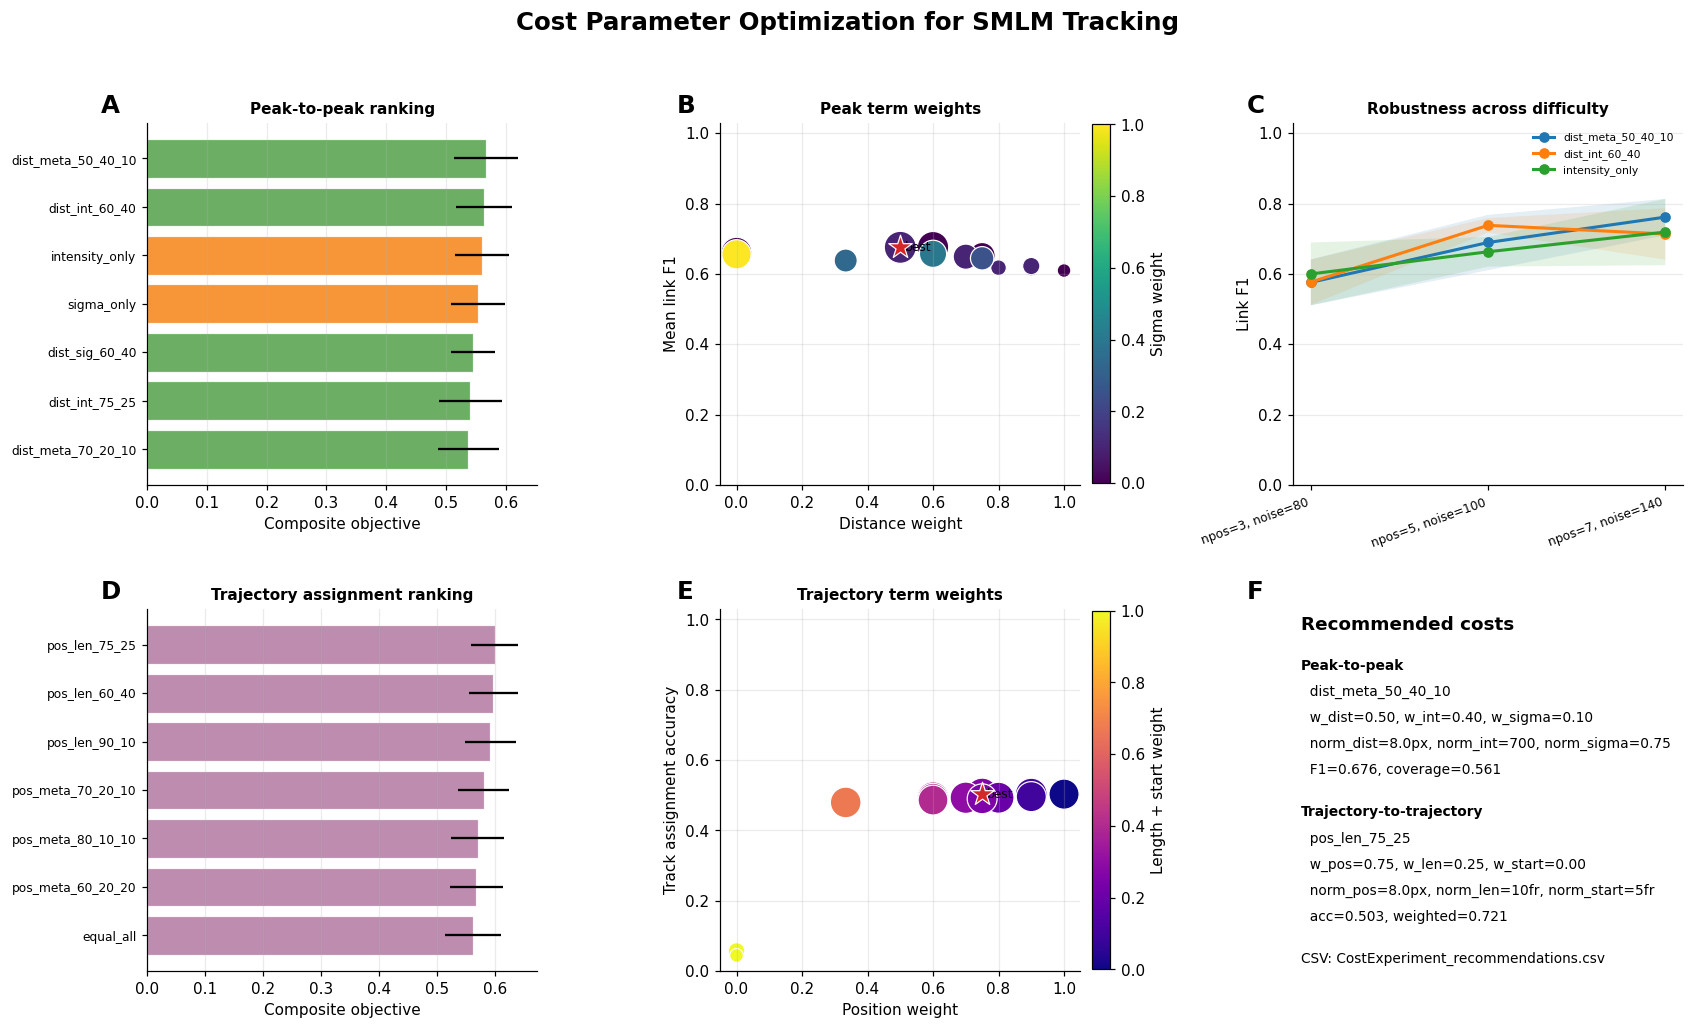

Saved report-ready figure:
- C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Experiments\CostExperiment_key_panels.png
- C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Experiments\CostExperiment_key_panels.pdf


In [8]:
COLORS = {
    "distance": "#4C78A8",
    "metadata": "#F58518",
    "all": "#54A24B",
    "traj": "#B279A2",
    "dark": "#1f2937",
}


def add_panel_label(ax, label):
    ax.text(
        -0.12,
        1.08,
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
        color="black",
    )


def config_family_color(name, stage="peak"):
    if stage == "peak":
        spec = next(s for s in PEAK_COST_SPECS if s["name"] == name)
        if spec["distance"] == 1:
            return COLORS["distance"]
        if spec["distance"] == 0:
            return COLORS["metadata"]
        return COLORS["all"]
    spec = next(s for s in TRAJ_COST_SPECS if s["name"] == name)
    if spec["position"] == 1:
        return COLORS["distance"]
    if spec["position"] == 0:
        return COLORS["metadata"]
    return COLORS["traj"]


def plot_top_bars(ax, summary, config_col, objective_col, stage, top_n=7):
    data = summary.head(top_n).iloc[::-1]
    y = np.arange(len(data))
    colors = [config_family_color(name, stage=stage) for name in data[config_col]]
    ax.barh(
        y,
        data[f"{objective_col}_mean"],
        xerr=data[f"{objective_col}_ci95"].fillna(0),
        color=colors,
        alpha=0.86,
        edgecolor="white",
        linewidth=0.8,
    )
    ax.set_yticks(y)
    ax.set_yticklabels(data[config_col], fontsize=8)
    ax.set_xlabel("Composite objective")
    ax.grid(axis="x", alpha=0.25)


def plot_peak_weight_scatter(ax):
    grouped = peak_df.groupby("peak_config").agg(
        link_f1=("link_f1", "mean"),
        objective=("peak_objective", "mean"),
        distance=("peak_distance_weight", "first"),
        intensity=("peak_intensity_weight", "first"),
        sigma=("peak_sigma_weight", "first"),
    ).reset_index()
    spread = max(1e-9, grouped["objective"].max() - grouped["objective"].min())
    sizes = 80 + 360 * (grouped["objective"] - grouped["objective"].min()) / spread
    sc = ax.scatter(
        grouped["distance"],
        grouped["link_f1"],
        c=grouped["sigma"],
        s=sizes,
        cmap="viridis",
        edgecolor="white",
        linewidth=0.8,
    )
    best = grouped.loc[grouped["peak_config"] == best_peak_name].iloc[0]
    ax.scatter(best["distance"], best["link_f1"], marker="*", s=260, color="#d62728", edgecolor="white", linewidth=0.8, zorder=5)
    ax.text(best["distance"] + 0.015, best["link_f1"], "best", va="center", fontsize=8)
    ax.set_xlabel("Distance weight")
    ax.set_ylabel("Mean link F1")
    ax.set_ylim(0, 1.03)
    ax.grid(alpha=0.25)
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label("Sigma weight")


def plot_peak_robustness(ax):
    top_names = peak_summary.head(3)["peak_config"].tolist()
    order = [f"npos={npos}, noise={noise}" for npos, noise in DIFFICULTY_GRID]
    x = np.arange(len(order))
    for name in top_names:
        sub = peak_df[peak_df["peak_config"] == name]
        grouped = sub.groupby("difficulty")["link_f1"].agg(["mean", "sem"]).reindex(order)
        y = grouped["mean"].to_numpy(dtype=float)
        e = (1.96 * grouped["sem"].fillna(0)).to_numpy(dtype=float)
        ax.plot(x, y, marker="o", linewidth=2, label=name)
        ax.fill_between(x, y - e, y + e, alpha=0.12)
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("Link F1")
    ax.set_ylim(0, 1.03)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=7, frameon=False)


def plot_traj_weight_scatter(ax):
    grouped = traj_df.groupby("traj_config").agg(
        accuracy=("assignment_accuracy", "mean"),
        weighted_accuracy=("assignment_weighted_accuracy", "mean"),
        objective=("traj_objective", "mean"),
        position=("traj_position_weight", "first"),
        length=("traj_length_weight", "first"),
        start=("traj_start_frame_weight", "first"),
    ).reset_index()
    meta = grouped["length"] + grouped["start"]
    spread = max(1e-9, grouped["objective"].max() - grouped["objective"].min())
    sizes = 80 + 360 * (grouped["objective"] - grouped["objective"].min()) / spread
    sc = ax.scatter(
        grouped["position"],
        grouped["accuracy"],
        c=meta,
        s=sizes,
        cmap="plasma",
        edgecolor="white",
        linewidth=0.8,
    )
    best = grouped.loc[grouped["traj_config"] == best_traj_name].iloc[0]
    ax.scatter(best["position"], best["accuracy"], marker="*", s=260, color="#d62728", edgecolor="white", linewidth=0.8, zorder=5)
    ax.text(best["position"] + 0.015, best["accuracy"], "best", va="center", fontsize=8)
    ax.set_xlabel("Position weight")
    ax.set_ylabel("Track assignment accuracy")
    ax.set_ylim(0, 1.03)
    ax.grid(alpha=0.25)
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label("Length + start weight")


def plot_recommendation_table(ax):
    ax.axis("off")
    peak_row = peak_summary.iloc[0]
    traj_row = traj_summary.iloc[0]
    lines = [
        "Recommended costs",
        "",
        "Peak-to-peak",
        f"  {best_peak_name}",
        f"  w_dist={best_peak_spec['distance']:.2f}, w_int={best_peak_spec['intensity']:.2f}, w_sigma={best_peak_spec['sigma']:.2f}",
        f"  norm_dist={PEAK_NORMS['distance']:.1f}px, norm_int={PEAK_NORMS['intensity']:.0f}, norm_sigma={PEAK_NORMS['sigma']:.2f}",
        f"  F1={peak_row['link_f1_mean']:.3f}, coverage={peak_row['mean_coverage_mean']:.3f}",
        "",
        "Trajectory-to-trajectory",
        f"  {best_traj_name}",
        f"  w_pos={best_traj_spec['position']:.2f}, w_len={best_traj_spec['length']:.2f}, w_start={best_traj_spec['start_frame']:.2f}",
        f"  norm_pos={TRAJ_NORMS['position']:.1f}px, norm_len={TRAJ_NORMS['length']:.0f}fr, norm_start={TRAJ_NORMS['start_frame']:.0f}fr",
        f"  acc={traj_row['assignment_accuracy_mean']:.3f}, weighted={traj_row['assignment_weighted_accuracy_mean']:.3f}",
        "",
        f"CSV: {RESULT_PATHS['summary'].name}",
    ]
    y = 0.98
    for line in lines:
        weight = "bold" if line in {"Recommended costs", "Peak-to-peak", "Trajectory-to-trajectory"} else "normal"
        size = 12 if line == "Recommended costs" else 9
        ax.text(0.02, y, line, transform=ax.transAxes, ha="left", va="top", fontsize=size, fontweight=weight)
        y -= 0.072 if line else 0.045


fig, axes = plt.subplots(2, 3, figsize=(15.5, 9.4))
axes = axes.ravel()

plot_top_bars(axes[0], peak_summary, "peak_config", "peak_objective", stage="peak")
axes[0].set_title("Peak-to-peak ranking", fontsize=10)
plot_peak_weight_scatter(axes[1])
axes[1].set_title("Peak term weights", fontsize=10)
plot_peak_robustness(axes[2])
axes[2].set_title("Robustness across difficulty", fontsize=10)
plot_top_bars(axes[3], traj_summary, "traj_config", "traj_objective", stage="traj")
axes[3].set_title("Trajectory assignment ranking", fontsize=10)
plot_traj_weight_scatter(axes[4])
axes[4].set_title("Trajectory term weights", fontsize=10)
plot_recommendation_table(axes[5])

for label, ax in zip("ABCDEF", axes):
    add_panel_label(ax, label)

fig.suptitle("Cost Parameter Optimization for SMLM Tracking", fontsize=16, fontweight="bold", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.965], w_pad=2.2, h_pad=2.0)
fig.savefig(RESULT_PATHS["figure_png"], bbox_inches="tight")
fig.savefig(RESULT_PATHS["figure_pdf"], bbox_inches="tight")
plt.show()

print("Saved report-ready figure:")
print(f"- {RESULT_PATHS['figure_png']}")
print(f"- {RESULT_PATHS['figure_pdf']}")

## Reusable recommended cost objects

Run this cell after the sweep to get the recommended cost functions for subsequent notebooks.

In [9]:
recommended_peak2peak_cost = build_peak_cost(best_peak_spec)
recommended_traj2traj_cost = build_traj_cost(best_traj_spec)

print("Use these objects in sim.track(...):")
print("cost_func_peak2peak=recommended_peak2peak_cost")
print("cost_func_traj2traj=recommended_traj2traj_cost")

Use these objects in sim.track(...):
cost_func_peak2peak=recommended_peak2peak_cost
cost_func_traj2traj=recommended_traj2traj_cost
